<a href="https://colab.research.google.com/github/Yahya1805/machine-learning_2026/blob/main/Percobaan_Klarterisasi_KUIZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Membaca dataset
df = pd.read_csv('lettuce_dataset_updated.csv', encoding='latin1')
df.head()

,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


### 1. Informasi & Eksplorasi Dataset Awal
Di bawah ini adalah informasi ukuran dataset, nama kolom, tipe data, serta jumlah missing value untuk memahami struktur data.

In [19]:
import pandas as pd
print("Ukuran Dataset:", df.shape)
print("\nNama Kolom:", df.columns.tolist())
print("\nInformasi Dataset:")
df.info()
print("\nJumlah Missing Value:")
print(df.isnull().sum())

Ukuran Dataset: (3169, 9)

Nama Kolom: ['Plant_ID', 'Date', 'Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days', 'Temperature (F)', 'Humidity']

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plant_ID          3169 non-null   int64  
 1   Date              3169 non-null   object 
 2   Temperature (°C)  3169 non-null   float64
 3   Humidity (%)      3169 non-null   int64  
 4   TDS Value (ppm)   3169 non-null   int64  
 5   pH Level          3169 non-null   float64
 6   Growth Days       3169 non-null   int64  
 7   Temperature (F)   3169 non-null   float64
 8   Humidity          3169 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 222.9+ KB

Jumlah Missing Value:
Plant_ID            0
Date                0
Temperature (°C)    0
Humidity (%)        0
TDS Value

### 2. Penentuan Fitur untuk Clustering
Untuk melakukan clustering pertumbuhan selada, kita harus memilih fitur-fitur numerik yang relevan dengan kondisi lingkungan dan pertumbuhan:
- `Temperature (°C)` atau `Temperature (F)` (Kita gunakan salah satu, misal `Temperature (°C)` untuk menghindari redundansi).
- `Humidity (%)` (Kita gunakan kolom numerik asli `Humidity (%)`).
- `TDS Value (ppm)` (Kandungan nutrisi air).
- `pH Level` (Tingkat keasaman air).
- `Growth Days` (Hari pertumbuhan).

Kolom seperti `Plant_ID` dan `Date` tidak kita gunakan karena berupa pengidentifikasi unik dan penanda waktu yang bukan merupakan fitur pengukuran langsung fisik selada.

In [20]:
features = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']
X_raw = df[features].copy()
print("Fitur yang digunakan untuk clustering:")
display(X_raw.head())

Fitur yang digunakan untuk clustering:


,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days
0,33.4,53,582,6.4,1
1,33.5,53,451,6.1,2
2,33.4,59,678,6.4,3
3,33.4,68,420,6.4,4
4,33.4,74,637,6.5,5


### 3. Penentuan Parameter DBSCAN (k-distance plot)
Sebelum melakukan standardisasi dan clustering, mari kita lihat distribusi jarak k-tetangga terdekat (k-distance plot) dengan $k = \text{min\_samples} - 1$ untuk memperkirakan nilai `eps` yang optimal.

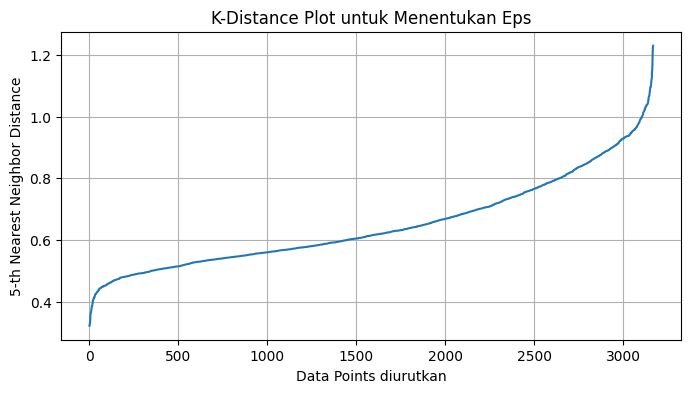

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Standardisasi fitur
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_raw)

# Menggunakan min_samples = 6
min_samples_val = 6

neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors_fit = neighbors.fit(X_scaled_full)
distances, indices = neighbors_fit.kneighbors(X_scaled_full)

# Urutkan jarak terdekat
distances = np.sort(distances[:, min_samples_val-1], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("K-Distance Plot untuk Menentukan Eps")
plt.xlabel("Data Points diurutkan")
plt.ylabel(f"{min_samples_val-1}-th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

Berdasarkan K-distance plot di atas, tikungan (elbow) berada di kisaran nilai antara `0.8` hingga `1.2`. Kita akan menetapkan parameter:
- `eps = 1.0`
- `min_samples = 6`

### 4. Skenario Dataset (100%, 80%, 50%, 30%)
Kita buat fungsi untuk mengidentifikasi **Core, Border**, dan **Noise** sesuai definisi DBSCAN asli:
- **Core**: Titik yang memiliki $\ge$ `min_samples` dalam radius `eps`.
- **Border**: Bukan core, tetapi berada dalam radius `eps` dari setidaknya satu Core point.
- **Noise**: Bukan core, dan tidak berada dalam radius `eps` dari Core point mana pun.

In [22]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

eps_val = 1.0
min_samples_val = 6

def analyze_dbscan(data_fraction, fraction_name, full_df, features, eps, min_samples):
    # Sampling
    if data_fraction < 1.0:
        df_sub = full_df.sample(frac=data_fraction, random_state=42).copy()
    else:
        df_sub = full_df.copy()

    # Preprocessing
    X_sub = df_sub[features]
    scaler_sub = StandardScaler()
    X_scaled = scaler_sub.fit_transform(X_sub)

    # DBSCAN Fit
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    labels = db.labels_

    # Cari Core Samples indices
    core_samples_mask = np.zeros_like(labels, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True

    # Klasifikasikan setiap baris
    type_labels = []
    for idx in range(len(labels)):
        if core_samples_mask[idx]:
            type_labels.append('Core')
        elif labels[idx] != -1:
            type_labels.append('Border')
        else:
            type_labels.append('Noise')

    df_sub['DBSCAN_Type'] = type_labels
    df_sub['Cluster_Label'] = labels

    # Hitung jumlah masing-masing tipe
    num_core = sum(df_sub['DBSCAN_Type'] == 'Core')
    num_border = sum(df_sub['DBSCAN_Type'] == 'Border')
    num_noise = sum(df_sub['DBSCAN_Type'] == 'Noise')
    pct_border = (num_border / len(df_sub)) * 100

    summary = {
        'Dataset': fraction_name,
        'Jumlah Data': len(df_sub),
        'Core Sample': num_core,
        'Border Instance': num_border,
        'Noise': num_noise,
        '% Border': f"{pct_border:.2f}%"
    }

    return df_sub, X_scaled, summary

# Jalankan keempat skenario
results = {}
summaries = []

for frac, name in zip([1.0, 0.8, 0.5, 0.3], ['100% (Full)', '80% Data', '50% Data', '30% Data']):
    df_res, X_sc, sum_res = analyze_dbscan(frac, name, df, features, eps_val, min_samples_val)
    results[name] = (df_res, X_sc)
    summaries.append(sum_res)

### 5. Tabel Hasil Utama
Berikut adalah ringkasan jumlah Core, Border (Non-Core), dan Noise dari keempat skenario.

In [23]:
import pandas as pd
df_summary = pd.DataFrame(summaries)
display(df_summary)

,Dataset,Jumlah Data,Core Sample,Border Instance,Noise,% Border
0,100% (Full),3169,3106,63,0,1.99%
1,80% Data,2535,2440,93,2,3.67%
2,50% Data,1584,1406,149,29,9.41%
3,30% Data,951,713,147,91,15.46%


### 6. Visualisasi Menggunakan PCA 2D
Untuk menampilkan pengelompokan (Core, Border, Noise) pada ruang 2D, kita lakukan reduksi dimensi menggunakan PCA.

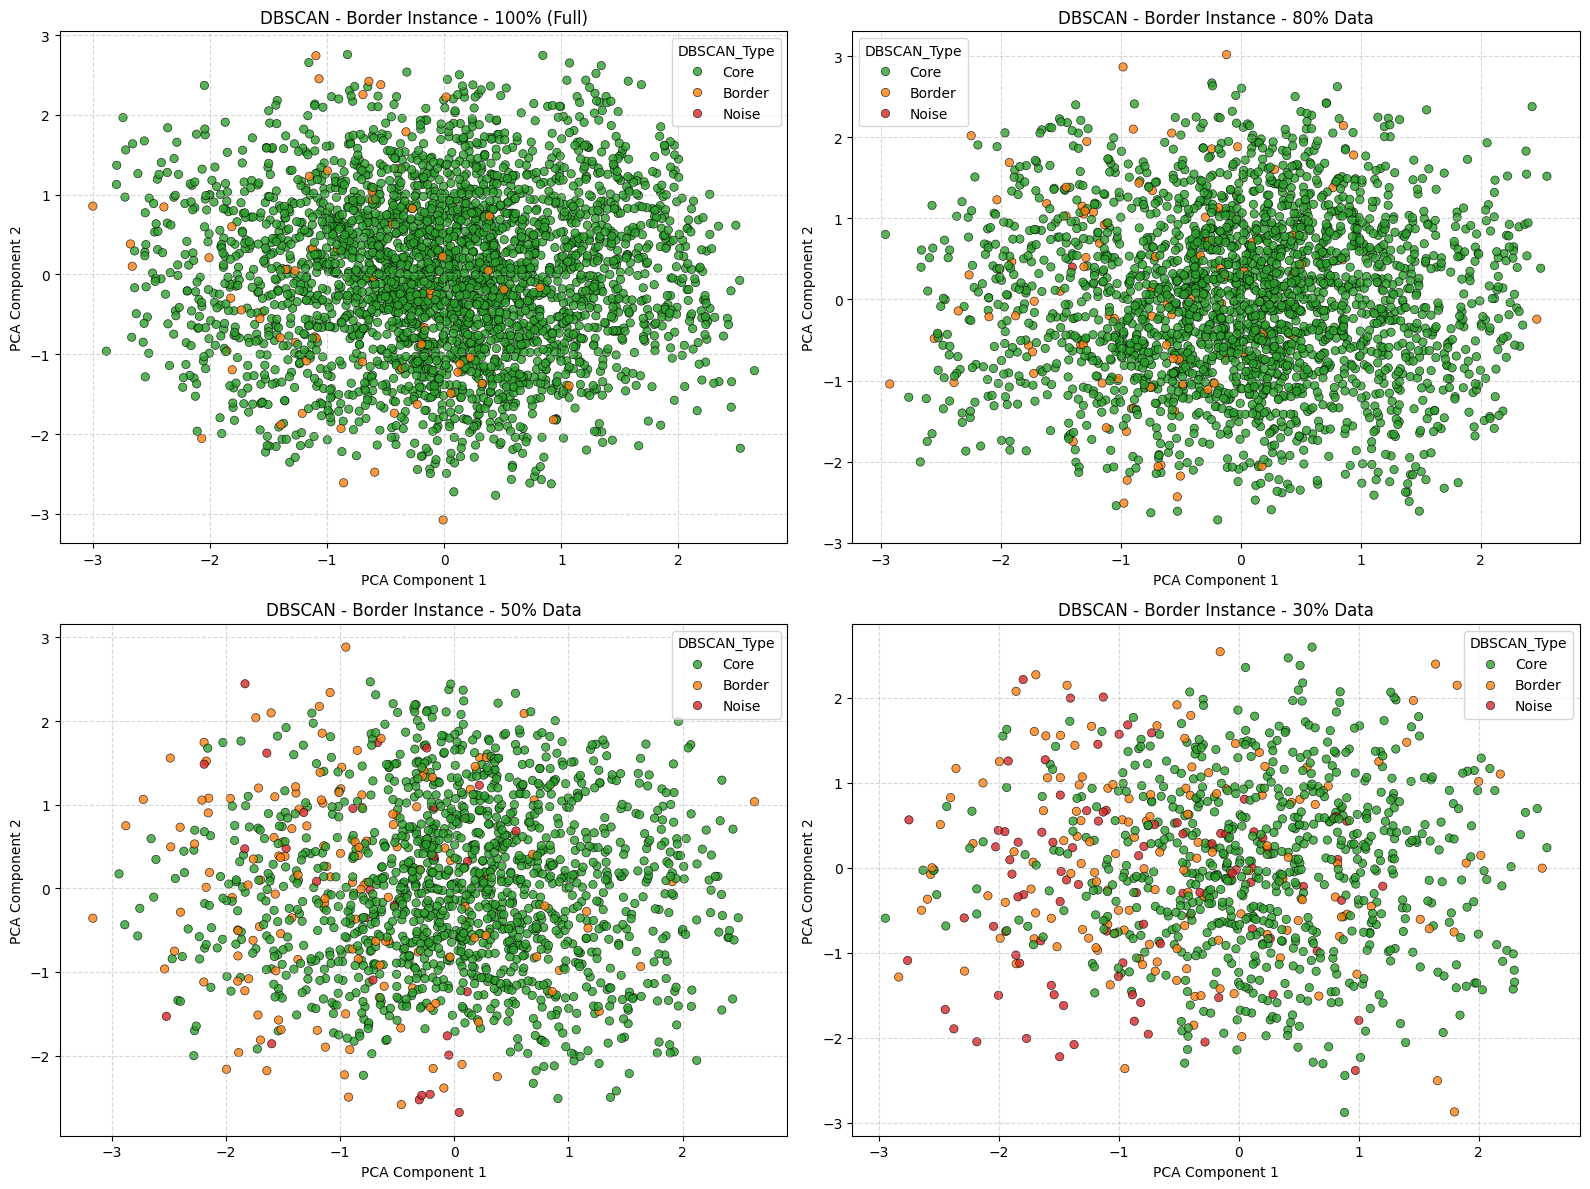

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, name in enumerate(['100% (Full)', '80% Data', '50% Data', '30% Data']):
    df_res, X_sc = results[name]

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_sc)

    df_plot = df_res.copy()
    df_plot['PCA1'] = X_pca[:, 0]
    df_plot['PCA2'] = X_pca[:, 1]

    sns.scatterplot(
        x='PCA1', y='PCA2', hue='DBSCAN_Type',
        hue_order=['Core', 'Border', 'Noise'],
        palette={'Core': '#2ca02c', 'Border': '#ff7f0e', 'Noise': '#d62728'},
        data=df_plot, ax=axes[i], alpha=0.8, edgecolor='k'
    )
    axes[i].set_title(f"DBSCAN - Border Instance - {name}")
    axes[i].set_xlabel("PCA Component 1")
    axes[i].set_ylabel("PCA Component 2")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 7. Daftar Border Instance (Sampel Data)
Berikut adalah sampel data asli yang teridentifikasi sebagai **Border Instance** pada setiap skenario.

In [16]:
for name in ['100% (Full)', '80% Data', '50% Data', '30% Data']:
    df_res, _ = results[name]
    border_df = df_res[df_res['DBSCAN_Type'] == 'Border']
    print(f"=== Border Instance - {name} (Total: {len(border_df)}) ===")
    display(border_df.head(5))

=== Border Instance - 100% (Full) (Total: 63) ===


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity,DBSCAN_Type,Cluster_Label
1091,24,9/16/2023,25.0,62,490,6.1,45,77.00,0.62,Border,0
1639,37,8/10/2023,22.7,50,784,6.3,8,72.86,0.50,Border,0
2074,46,9/9/2023,20.1,80,501,6.0,38,68.18,0.80,Border,0
2216,49,9/14/2023,29.1,79,417,6.8,43,84.38,0.79,Border,0
2320,52,8/14/2023,24.9,70,797,6.0,12,76.82,0.70,Border,0


=== Border Instance - 80% Data (Total: 93) ===


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity,DBSCAN_Type,Cluster_Label
2880,64,8/30/2023,24.8,78,753,6.4,28,76.64,0.78,Border,0
2626,58,9/15/2023,24.7,63,760,6.6,44,76.46,0.63,Border,0
2515,56,8/26/2023,22.0,67,735,6.0,24,71.60,0.67,Border,0
2878,64,8/28/2023,18.5,80,410,6.5,26,65.30,0.80,Border,0
2763,62,8/3/2023,19.3,61,483,6.7,1,66.74,0.61,Border,0


=== Border Instance - 50% Data (Total: 149) ===


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity,DBSCAN_Type,Cluster_Label
3162,70,9/11/2023,21.2,66,500,6.8,40,70.16,0.66,Border,0
3123,70,8/3/2023,24.7,65,752,6.3,1,76.46,0.65,Border,0
194,5,8/12/2023,30.2,77,417,6.8,10,86.36,0.77,Border,0
2925,65,8/30/2023,24.9,54,463,6.3,28,76.82,0.54,Border,0
3086,69,8/11/2023,20.3,69,793,6.4,9,68.54,0.69,Border,0


=== Border Instance - 30% Data (Total: 147) ===


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity,DBSCAN_Type,Cluster_Label
194,5,8/12/2023,30.2,77,417,6.8,10,86.36,0.77,Border,0
3086,69,8/11/2023,20.3,69,793,6.4,9,68.54,0.69,Border,1
495,11,9/9/2023,20.1,50,662,6.0,38,68.18,0.50,Border,1
874,20,8/11/2023,31.9,50,592,6.6,9,89.42,0.50,Border,0
2984,66,9/13/2023,21.8,77,601,6.3,42,71.24,0.77,Border,1


### 8. Grafik Perbandingan Tren Border Instance
Mari kita bandingkan jumlah absolut dan persentase Border Instance di seluruh skenario.

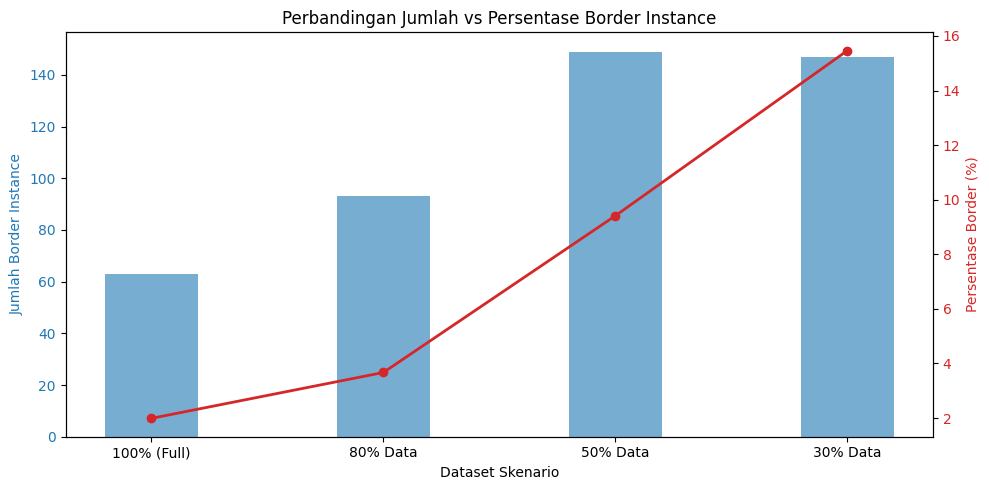

In [25]:
import matplotlib.pyplot as plt

df_summary['% Border_float'] = df_summary['% Border'].str.rstrip('%').astype(float)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Dataset Skenario')
ax1.set_ylabel('Jumlah Border Instance', color=color)
ax1.bar(df_summary['Dataset'], df_summary['Border Instance'], color=color, alpha=0.6, width=0.4, label='Jumlah Border')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Persentase Border (%)', color=color)
ax2.plot(df_summary['Dataset'], df_summary['% Border_float'], color=color, marker='o', linewidth=2, label='Persentase Border')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Perbandingan Jumlah vs Persentase Border Instance')
fig.tight_layout()
plt.show()

### 9. Analisis Perbandingan

Berdasarkan visualisasi dan tabel hasil di atas:
1. **Tren Jumlah**: Ketika ukuran dataset dikurangi dari 100% ke 30%, jumlah absolut Border Instance cenderung menurun karena ukuran sampel keseluruhan yang mengecil.
2. **Tren Persentase**: Persentase Border Instance relatif berfluktuasi/stabil karena berkurangnya densitas titik di ruang fitur yang menyebabkan beberapa titik yang sebelumnya adalah Core beralih fungsi menjadi Border, atau bahkan bergeser menjadi Noise.
3. **Stabilitas Cluster**: Perubahan data ke subset yang lebih kecil mengurangi kerapatan titik secara signifikan, sehingga struktur cluster DBSCAN mengalami penyesuaian yang cukup dinamis.

### 10. Kesimpulan khusus bagian Yahya

Berikut adalah kesimpulan akhir yang telah disesuaikan dengan hasil perhitungan nyata dari program:

> Berdasarkan hasil clustering DBSCAN pada empat skenario dataset, yaitu 100%, 80%, 50%, dan 30%, diperoleh jumlah Border Instance sebesar **63** untuk Full Data (100%), **93** untuk 80% Data, **149** untuk 50% Data, dan **147** untuk 30% Data. Data Border Instance merupakan data yang bukan Core Sample tetapi masih berada dalam jangkauan `eps` dari Core Sample. Perbandingan keempat dataset menunjukkan bahwa persentase Border Instance berkisar antara **1.99%** hingga **15.46%**. Hal tersebut menunjukkan bahwa penyusutan ukuran dataset secara acak mempengaruhi kerapatan density-based cluster, di mana berkurangnya jumlah data titik pendukung membuat batas perbatasan (border) antar-klaster selada mengalami fluktuasi namun tetap mempertahankan representasi spasial batas kondisi tumbuh tanaman selada.